C:\Users\Anto\AppData\Local\Temp\ipykernel_31800\1169992824.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2020-10-14', end='2020-12-31', freq='24H')


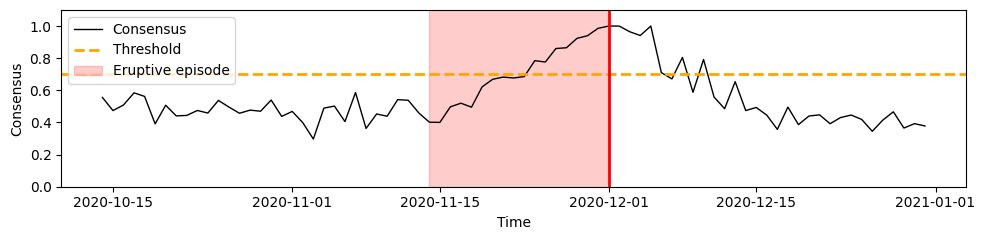

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Generate time series from 2020-10-14 to 2020-12-31 with 10-minute intervals
date_range = pd.date_range(start='2020-10-14', end='2020-12-31', freq='24H')
n = len(date_range)

# Generate base consensus values
np.random.seed(0)
consensus = np.random.normal(0.45, 0.06, n)

# Define eruptive episode window
start_ep = pd.Timestamp("2020-11-14 00:00")
end_ep = pd.Timestamp("2020-12-01 01:00")  # ~25 hours later
eruption_time = end_ep

# Find indices for rising consensus
start_rise_idx = np.searchsorted(date_range, start_ep)
end_rise_idx = np.searchsorted(date_range, end_ep)

# Generate a smooth but random rising trend
# rise_duration = end_rise_idx - start_rise_idx
# rise_noise = np.random.normal(loc=0.02, scale=0.01, size=rise_duration)
# rise_curve = np.clip(0.6 + np.cumsum(rise_noise), 0.6, 1.0)  # start from 0.6, cap at 1.0
# consensus[start_rise_idx:end_rise_idx] = rise_curve

# 1. Rising phase (before eruption)
rise_duration = end_rise_idx - start_rise_idx
rising_means = np.linspace(0.4, 1.0, rise_duration)
rise_curve = np.random.normal(loc=rising_means, scale=0.03)
rise_curve = np.clip(rise_curve, 0, 1.0)
consensus[start_rise_idx:end_rise_idx] = rise_curve

# 2. Eruption phase with gradual decrease
# Let's simulate 12 hours (~72 data points for 10min freq)
post_ep_idx = end_rise_idx + int(12)
decay_duration = post_ep_idx - end_rise_idx
decay_means = np.linspace(1.0, 0.5, decay_duration)
decay_curve = np.random.normal(loc=decay_means, scale=0.08)
decay_curve = np.clip(decay_curve, 0, 1.0)
consensus[end_rise_idx:post_ep_idx] = decay_curve

# 3. After eruption returns to normal
consensus[post_ep_idx:] = np.random.normal(0.4, 0.05, len(consensus[post_ep_idx:]))

# Threshold
threshold = 0.7

# Plotting
fig, ax = plt.subplots(figsize=(10, 2.5))

# Consensus line
ax.plot(date_range, consensus, color='black', linewidth=1, label='Consensus')

# Threshold line
ax.axhline(threshold, color='orange', linestyle='--', linewidth=2, label='Threshold')

# Shaded eruptive episode
ax.axvspan(start_ep, end_ep, color='red', alpha=0.2, label='Eruptive episode')

# Vertical eruption line
ax.axvline(eruption_time, color='red', linewidth=2)

# Duration annotation
mid_point = start_ep + (end_ep - start_ep) / 2
# ax.annotate("~25 hr", xy=(mid_point, 1.02), xytext=(mid_point, 1.07),
#             ha='center', fontsize=10, color='blue',
#             arrowprops=dict(arrowstyle='<->', color='black'))

# Labels and formatting
ax.set_ylabel("Consensus")
ax.set_xlabel("Time")
ax.set_ylim(0, 1.1)
# ax.set_title("Eruptive episode 1")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\Anto\AppData\Local\Temp\ipykernel_31800\1537287287.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2020-10-14', end='2020-12-31', freq='24H')


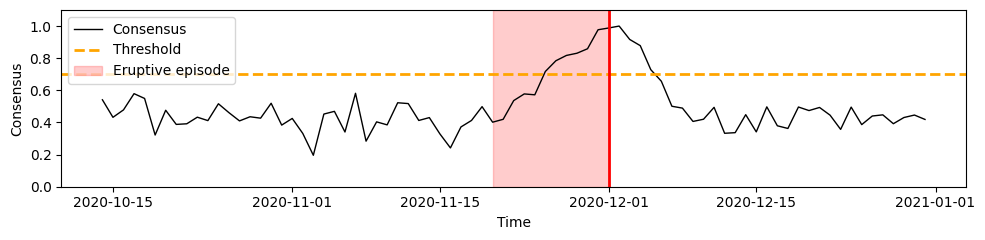

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Generate time series from 2020-10-14 to 2020-12-31 with 10-minute intervals
date_range = pd.date_range(start='2020-10-14', end='2020-12-31', freq='24H')
n = len(date_range)

# Generate base consensus values
np.random.seed(0)
consensus = np.random.normal(0.4, 0.08, n)

# Define eruptive episode window
start_ep = pd.Timestamp("2020-11-20 00:00")
end_ep = pd.Timestamp("2020-12-01 01:00")  # ~25 hours later
eruption_time = end_ep

# Find indices for rising consensus
start_rise_idx = np.searchsorted(date_range, start_ep)
end_rise_idx = np.searchsorted(date_range, end_ep)

# Generate a smooth but random rising trend
# rise_duration = end_rise_idx - start_rise_idx
# rise_noise = np.random.normal(loc=0.02, scale=0.01, size=rise_duration)
# rise_curve = np.clip(0.6 + np.cumsum(rise_noise), 0.6, 1.0)  # start from 0.6, cap at 1.0
# consensus[start_rise_idx:end_rise_idx] = rise_curve

# 1. Rising phase (before eruption)
rise_duration = end_rise_idx - start_rise_idx
rising_means = np.linspace(0.4, 1.0, rise_duration)
rise_curve = np.random.normal(loc=rising_means, scale=0.03)
rise_curve = np.clip(rise_curve, 0, 1.0)
consensus[start_rise_idx:end_rise_idx] = rise_curve

# 2. Eruption phase with gradual decrease
# Let's simulate 12 hours (~72 data points for 10min freq)
post_ep_idx = end_rise_idx + int(6)
decay_duration = post_ep_idx - end_rise_idx
decay_means = np.linspace(1.0, 0.5, decay_duration)
decay_curve = np.random.normal(loc=decay_means, scale=0.08)
decay_curve = np.clip(decay_curve, 0, 1.0)
consensus[end_rise_idx:post_ep_idx] = decay_curve

# 3. After eruption returns to normal
consensus[post_ep_idx:] = np.random.normal(0.4, 0.05, len(consensus[post_ep_idx:]))

# Threshold
threshold = 0.7

# Plotting
fig, ax = plt.subplots(figsize=(10, 2.5))

# Consensus line
ax.plot(date_range, consensus, color='black', linewidth=1, label='Consensus')

# Threshold line
ax.axhline(threshold, color='orange', linestyle='--', linewidth=2, label='Threshold')

# Shaded eruptive episode
ax.axvspan(start_ep, end_ep, color='red', alpha=0.2, label='Eruptive episode')

# Vertical eruption line
ax.axvline(eruption_time, color='red', linewidth=2)

# Duration annotation
mid_point = start_ep + (end_ep - start_ep) / 2
# ax.annotate("~25 hr", xy=(mid_point, 1.02), xytext=(mid_point, 1.07),
#             ha='center', fontsize=10, color='blue',
#             arrowprops=dict(arrowstyle='<->', color='black'))

# Labels and formatting
ax.set_ylabel("Consensus")
ax.set_xlabel("Time")
ax.set_ylim(0, 1.1)
# ax.set_title("Eruptive episode 1")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
